# Città 30 Through Data - Data Analisys
The goal of this project is to investigate the impact of Bologna Città30, a regulation that starting January 2024 imposes a speed limit of 30 km/h on most of the streets of the city.

## Tabel of content
1) Dataset Conversion (rdf to csv)
2) Bike Traffic
3) Car Traffic
4) 30 vs non30 Zones
5) Air Quality
6) Electric Vehicles

# 1 - Dataset conversion
This dataset, provided by the City of Bologna, provides data about hourly bicycle traffic counts collected continuously at various locations throughout the city.
For the San Donato, Parri, Ercolani, and Sabotino counters, data is updated monthly, while for all other counters updates are provided daily.

The dataset is accessible in RDF/XML format at [data.europa.eu](http://data.europa.eu/88u/dataset/c_a944-colonnine-conta-bici)

In this notebook the dataset is converted from the original RDF/XML into tabular format (CSV) for the sake of speed and ease of access in subsequent operations.

In [1]:
import xml.etree.ElementTree as ET
import csv
from pathlib import Path

## Specify input/output parameters
Edit the fields if needed

In [2]:
rdf_path = Path("../data/colonnine-conta-bici.rdf")
csv_path = Path("../data/colonnine-conta-bici.csv")

## Function Definitions

This cell defines two functions used to convert the `colonnine-conta-bici.rdf` file into a structured CSV.

The first function, `detect_namespace`, takes the root of the parsed RDF/XML tree and a local tag name (`colonnine-conta-bici-record`). It iterates through the XML elements to find the first occurrence of a tag with the given local name, then extracts and returns its associated namespace URI. This is necessary because RDF/XML uses fully qualified tag names that include the namespace in curly braces.

The second function, `rdfxml_to_csv`, handles the actual conversion process. It parses the RDF file, determines the namespace using `detect_namespace`, and finds all the `<colonnine-conta-bici-record>` elements. The function then extracts six predefined fields-`colonnina`, `totale`, `direzione_periferia`, `direzione_centro`, `geo_point_2d`, and `data`-from each record and writes them into a CSV file. Each field is retrieved as a direct child of the record element, and if a field is missing, an empty string is written in its place.

In [3]:
def detect_namespace(root, record_local_name: str) -> str:
    for elem in root.iter():
        if isinstance(elem.tag, str) and elem.tag.startswith("{"):
            uri, local = elem.tag[1:].split("}")
            if local == record_local_name:
                return uri
    raise ValueError(f"Tag record '{record_local_name}' not found")

def rdfxml_to_csv(rdf_path: Path, csv_path: Path):
    tree = ET.parse(rdf_path)
    root = tree.getroot()
    record_local = "colonnine-conta-bici-record"
    fields = ["colonnina","totale","direzione_periferia","direzione_centro","geo_point_2d","data"]
    ns_uri = detect_namespace(root, record_local)
    ns = {"ns": ns_uri}
    records = root.findall(f".//ns:{record_local}", ns)
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(fields)
        for rec in records:
            row = []
            for fld in fields:
                el = rec.find(f"ns:{fld}", ns)
                row.append(el.text.strip() if el is not None and el.text else "")
            writer.writerow(row)
    print(f"[OK] {len(records)} records written in {csv_path}")

In [4]:
rdfxml_to_csv(rdf_path, csv_path)

FileNotFoundError: [Errno 2] No such file or directory: '..\\data\\colonnine-conta-bici.rdf'

## Exemplar table visualization
Visualize the first 10 rows of the dataset

In [5]:
import pandas as pd

df = pd.read_csv(csv_path)

pd.set_option('display.max_columns', None)

display(df.head(10))


,colonnina,totale,direzione_periferia,direzione_centro,geo_point_2d,data
0,Orti_II,3.0,3.0,NaN,"44.47624162079627,11.37609044129954",2025-06-09 21:00:00+00:00
1,Murri_I,5.0,5.0,NaN,"44.48440745989066,11.35658715560829",2025-06-09 20:00:00+00:00
2,Mazzini_II,130.0,NaN,130.0,"44.48936290709702,11.35940582976347",2025-06-10 05:00:00+00:00
3,Sturzo_II,14.0,14.0,NaN,"44.48820778081575,11.29599058158018",2025-06-10 07:00:00+00:00
4,Massarenti_II,33.0,NaN,33.0,"44.49300884795814,11.37056742338153",2025-06-10 02:00:00+00:00
5,Zanardi_I,NaN,NaN,NaN,"44.50817288812807,11.32990298071598",2025-06-09 22:00:00+00:00
6,Murri_II,7.0,NaN,7.0,"44.48418981668801,11.35719458905058",2025-06-09 21:00:00+00:00
7,Zanardi_II,191.0,191.0,NaN,"44.5082267800901,11.32964907760978",2025-06-10 04:00:00+00:00
8,Zanardi_II,1.0,1.0,NaN,"44.5082267800901,11.32964907760978",2025-06-09 20:00:00+00:00
9,Zanardi_II,68.0,68.0,NaN,"44.5082267800901,11.32964907760978",2025-06-10 08:00:00+00:00


## Merge Bike Counter Data with 2024 Speed Limits and Trim for ease-of-access

In this section we will integrate data from the dataset obtained as the result of the conversion with another dataset about speed limits in Bologna (accessible [here](https://opendata.comune.bologna.it/explore/dataset/velocita-citta-30/)).

To do so we will:

1. Load and filter bike counter readings from January 16th 2024 onward
2. Load the 2024 speed‐limit dataset, where streets are represented as LineString/MultiLineString
3. Perform a spatial “nearest” join to associate each bike counter point with the speed limit of the closest street segment
4. Export the merged result to a new CSV file
5. Trim the dataset to daily measurements

In [6]:
import json
from pathlib import Path

import pandas as pd            # tabular data handling
import geopandas as gpd        # spatial data handling
from shapely.geometry import Point, shape  # point & geojson→geometry

## File paths

Modify these paths as needed to point to your downloaded files.

In [7]:
# Path to the CSV of bike counters
bike_csv = Path("../data/colonnine-conta-bici.csv")

# Path to the speed limits CSV
speed_csv = Path("../data/velocita-citta-30.csv")

# Output path for the merged CSV
merged_csv = Path("../data/bike-merged.csv")

#Output path for the trimmed csv
trimmed_csv = Path("../data/bike-trimmed.csv")

## Define loader functions

Define two helper functions to read into GeoDataFrames:
- `load_bike_counters` reads all readings (no date filter) and parses points.
- `load_speed_limits` reads street lines (GeoJSON) and builds geometries.

In [8]:
def load_bike_counters(path: Path) -> gpd.GeoDataFrame:
    df = pd.read_csv(path, parse_dates=['data'])
    def to_point(s):
        if pd.isna(s): return None
        lat, lon = [x.strip() for x in s.split(',')]
        return Point(float(lon), float(lat))
    return gpd.GeoDataFrame(df,
                            geometry=df['geo_point_2d'].apply(to_point),
                            crs="EPSG:4326")

def load_speed_limits(path: Path) -> gpd.GeoDataFrame:
    df = pd.read_csv(path, sep=';', encoding='utf-8-sig')
    if 'Geo Shape' not in df:
        raise ValueError("Missing 'Geo Shape' column")
    def parse_shape(js):
        if pd.isna(js): return None
        return shape(json.loads(js))
    return gpd.GeoDataFrame(df,
                            geometry=df['Geo Shape'].apply(parse_shape),
                            crs="EPSG:4326")

## Mapping
Extract one representative point per column, perform a single nearest-neighbor join against street lines (in a metric CRS), and build a mapping DataFrame.

In [9]:
# 1) Load full bike data
bike_full = load_bike_counters(bike_csv)

# 2) Unique point per column
unique_pts = (bike_full
              .drop_duplicates(subset="colonnina")
              .loc[:, ["colonnina", "geometry"]]
              .to_crs(epsg=32632))

# 3) Load and reproject street lines
speed_gdf = load_speed_limits(speed_csv).to_crs(epsg=32632)

# 4) Spatial join once to get VEL2024 per colonnina
mapping = (gpd.sjoin_nearest(unique_pts,
                             speed_gdf[['VEL2024','geometry']],
                             how='left',
                             distance_col='dist_m')
           .drop(columns=['geometry','dist_m','index_right'])
           .set_index('colonnina')['VEL2024']
           .rename('VEL2024')
           .reset_index())

## Merge function

Merge the `VEL2024` mapping back onto all readings via pandas merge, drop geometry, and write out the final CSV.

In [10]:
# Ensure full dataset in lat/lon (merge ignores geometry)
bike_full = bike_full.to_crs(epsg=4326)

# Merge
merged = bike_full.merge(mapping, on="colonnina", how="left")

# Export (dropping geometry)
merged.drop(columns='geometry').to_csv(merged_csv, index=False)
print(f"[OK] {len(merged)} rows written to {merged_csv}")

[OK] 298436 rows written to ..\data\bike-merged.csv


## Exemplar Visualization
Load the merged CSV and display the first 10 rows with all columns.


In [11]:
df = pd.read_csv(merged_csv)
pd.set_option('display.max_columns', None)
display(df.head(10))

,colonnina,totale,direzione_periferia,direzione_centro,geo_point_2d,data,VEL2024
0,Orti_II,3.0,3.0,NaN,"44.47624162079627,11.37609044129954",2025-06-09 21:00:00+00:00,50
1,Murri_I,5.0,5.0,NaN,"44.48440745989066,11.35658715560829",2025-06-09 20:00:00+00:00,50
2,Mazzini_II,130.0,NaN,130.0,"44.48936290709702,11.35940582976347",2025-06-10 05:00:00+00:00,30
3,Sturzo_II,14.0,14.0,NaN,"44.48820778081575,11.29599058158018",2025-06-10 07:00:00+00:00,50
4,Massarenti_II,33.0,NaN,33.0,"44.49300884795814,11.37056742338153",2025-06-10 02:00:00+00:00,30
5,Zanardi_I,NaN,NaN,NaN,"44.50817288812807,11.32990298071598",2025-06-09 22:00:00+00:00,30
6,Murri_II,7.0,NaN,7.0,"44.48418981668801,11.35719458905058",2025-06-09 21:00:00+00:00,30
7,Zanardi_II,191.0,191.0,NaN,"44.5082267800901,11.32964907760978",2025-06-10 04:00:00+00:00,30
8,Zanardi_II,1.0,1.0,NaN,"44.5082267800901,11.32964907760978",2025-06-09 20:00:00+00:00,30
9,Zanardi_II,68.0,68.0,NaN,"44.5082267800901,11.32964907760978",2025-06-10 08:00:00+00:00,30


## Trim-to-daily function

In order to ease future processing of data, we run this Python script that:

1. **Reads** the raw hourly CSV (`bike-merged.csv`).  
2. **Parses** the timestamp column into a simple date for grouping.  
3. **Normalizes** counter names by stripping any `_I`/`_II` suffix so that split‐direction sensors merge into one.  
4. **Fills** missing hourly counts with zero to avoid gaps.  
5. **Groups** by (`colonnina`, `data`) and:
   - **Sums** all hourly counts into a daily total.  
   - **Carries over** the first observed `VEL2024` value for that counter.  
6. **Writes** the resulting daily summary to `bike-trimmed.csv`.

This will produce a clean dataset trimmed to daily measurements (instead of hourly).


In [12]:
import pandas as pd

# read input file
df = pd.read_csv(merged_csv)

# parse date from timestamp
df['data'] = pd.to_datetime(df['data']).dt.date

# strip suffix _I or _II to unify counters
df['colonnina'] = df['colonnina'].str.replace(r'(_I|_II)$', '', regex=True)

# fill missing counts
df['totale'] = df['totale'].fillna(0)

# sum hourly counts per day and counter, keep first VEL2024
daily = (
    df.groupby(['colonnina', 'data'], as_index=False)
      .agg(totale=('totale', 'sum'), VEL2024=('VEL2024', 'first'))
)

# write daily summary to CSV
daily.to_csv(trimmed_csv, index=False)

print(f"bike-trimmed.csv created with {len(daily)} records.")


bike-trimmed.csv created with 10718 records.


## Exemplar Visualization
Load the trimmed CSV and display the first 10 rows with all columns.


In [13]:
df = pd.read_csv(trimmed_csv)
pd.set_option('display.max_columns', None)
display(df.head(10))

,colonnina,data,totale,VEL2024
0,Ercolani,2018-12-31,19.0,50
1,Ercolani,2019-01-01,464.0,50
2,Ercolani,2019-01-02,816.0,50
3,Ercolani,2019-01-03,987.0,50
4,Ercolani,2019-01-04,1037.0,50
5,Ercolani,2019-01-05,704.0,50
6,Ercolani,2019-01-06,713.0,50
7,Ercolani,2019-01-07,1747.0,50
8,Ercolani,2019-01-08,1884.0,50
9,Ercolani,2019-01-09,1985.0,50


# 2 - Bike Traffic

This section is **customized** for the CSV **`bike-trimmed.csv`** which is the product of the execution of the previous section (Section 1) and contains the columns:
- `colonnina` (station name)
- `data` (date)
- `totale` (daily total count of bikes)
- `VEL2024` (context field, not used here)

We create several time‑series charts using only these columns.
> Prerequisite: matplotlib installed

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
%matplotlib inline

CSV_PATH = Path('../data/bike-trimmed.csv') # change path if needed

# Load csv
df = pd.read_csv(CSV_PATH, parse_dates=['data'])
df = df.rename(columns={'data': 'timestamp', 'colonnina': 'station', 'totale': 'count'})
df = df.dropna(subset=['timestamp', 'station', 'count']).copy()
df['count'] = pd.to_numeric(df['count'], errors='coerce')
df = df.dropna(subset=['count']).sort_values('timestamp').copy()

display(df.head(10))
print(f"Rows: {len(df):,} | Stations: {df['station'].nunique()} | Time span: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")

,station,timestamp,count,VEL2024
0,Ercolani,2018-12-31,19.0,50
5107,Sabotino,2018-12-31,11.0,50
1,Ercolani,2019-01-01,464.0,50
5108,Sabotino,2019-01-01,553.0,50
2,Ercolani,2019-01-02,816.0,50
5109,Sabotino,2019-01-02,868.0,50
3,Ercolani,2019-01-03,987.0,50
5110,Sabotino,2019-01-03,985.0,50
5111,Sabotino,2019-01-04,1063.0,50
4,Ercolani,2019-01-04,1037.0,50


Rows: 10,718 | Stations: 15 | Time span: 2018-12-31 → 2025-07-01


## Helper functions

Short utilities to aggregate and plot the data.

In [15]:
def resample_mean(df, freq):
    """Group by station and resample on timestamp using mean of 'count'."""
    g = (df.set_index('timestamp')
           .groupby('station')['count']
           .resample(freq)
           .mean()
           .rename('avg')
           .reset_index())
    return g

def plot_multiline(pivot_df, title, xlabel='Time', ylabel='Average Bikes'):
    fig, ax = plt.subplots(figsize=(10, 6))
    for col in pivot_df.columns:
        ax.plot(pivot_df.index, pivot_df[col], label=col)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(loc='best', ncol=2)
    ax.grid(True, linestyle='--', alpha=0.4)
    fig.tight_layout()
    plt.show()

def aggregate_half_year(df):
    """Aggregate to H1/H2 (semiannual) means per station."""
    tmp = df.copy()
    tmp['year'] = tmp['timestamp'].dt.year
    tmp['half'] = np.where(tmp['timestamp'].dt.month <= 6, 1, 2)
    agg = (tmp.groupby(['station','year','half'])['count']
              .mean()
              .rename('avg')
              .reset_index())
    # Representative period end for plotting (end of H1/H2)
    agg['period_end'] = pd.to_datetime(agg['year'].astype(str)) + pd.to_timedelta(agg['half']*6, unit='M') - pd.Timedelta(days=1)
    return agg

def make_index100_from_first(df_agg, value_col='avg'):
    """Within each station, normalize so the first available period == 100."""
    out = []
    for st, g in df_agg.groupby('station'):
        g = g.sort_values(g.columns[g.columns.str.contains('timestamp|period_end|date|time', case=False, regex=True)][0]).copy()
        base = g[value_col].iloc[0] if len(g) else np.nan
        g['index100'] = (g[value_col] / base) * 100.0 if base and not np.isnan(base) else np.nan
        out.append(g)
    return pd.concat(out, ignore_index=True) if out else df_agg.copy()

## Annual averages — all stations

**What this shows:** the **mean daily counts aggregated by year** for **each station**. This reveals overall trends and differences in magnitude across stations.

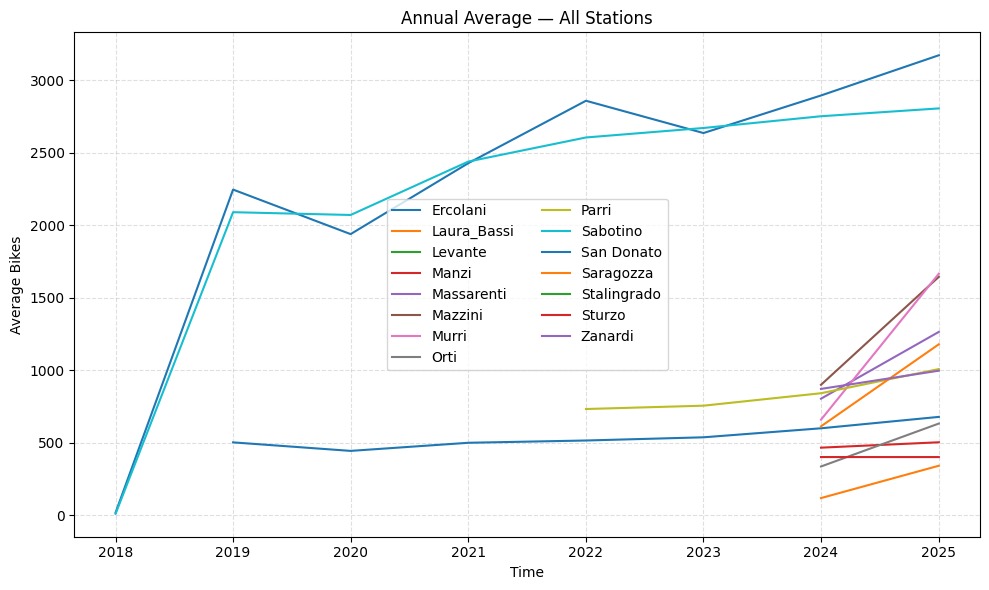

In [16]:
annual = resample_mean(df, 'YS')
piv = (annual.pivot(index='timestamp', columns='station', values='avg')
             .sort_index())
plot_multiline(piv, title='Annual Average — All Stations')

## Focus on the 3 stations present since 2019: *Ercolani*, *Sabotino*, *San Donato*

Below we compare these three long‑running stations at multiple time scales.

In [17]:
targets = ['Ercolani','Sabotino','San Donato']
df3 = df[df['station'].isin(targets)].copy()
missing = [t for t in targets if t not in df3['station'].unique()]
if missing:
    print("Warning: missing stations:", missing)
df3.head(3)

,station,timestamp,count,VEL2024
0,Ercolani,2018-12-31,19.0,50
5107,Sabotino,2018-12-31,11.0,50
1,Ercolani,2019-01-01,464.0,50


### Annual (3 stations)

**Why:** a high‑level comparison of year‑to‑year averages for the three stations.

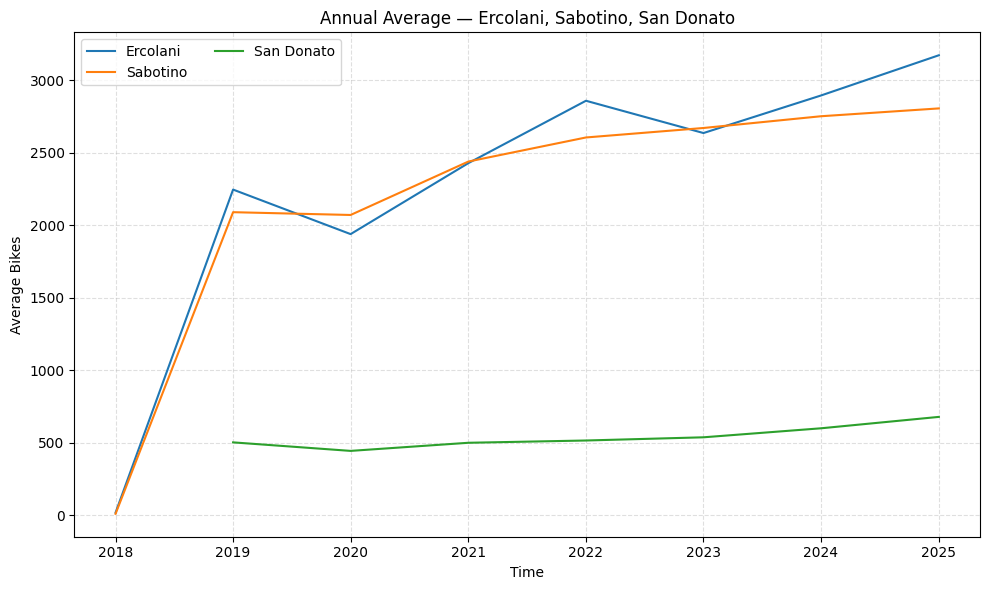

In [18]:
annual3 = resample_mean(df3, 'YS')
piv = (annual3.pivot(index='timestamp', columns='station', values='avg')
                 .sort_index())
plot_multiline(piv, title='Annual Average — Ercolani, Sabotino, San Donato')

### Quarterly (3 stations)

**Why:** quarterly smoothing balances noise and responsiveness, useful to spot seasonal patterns and medium‑term changes.

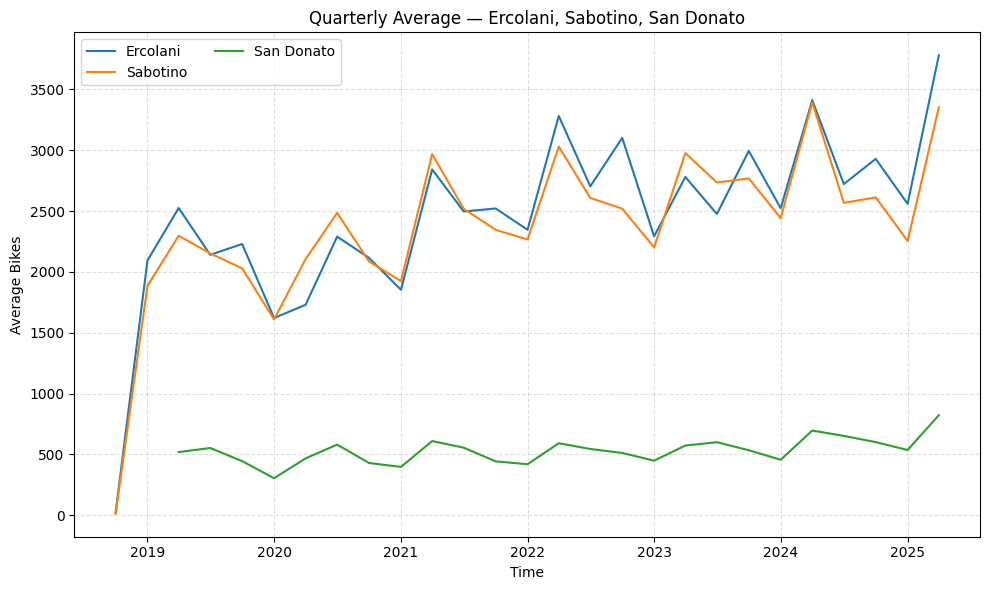

In [19]:
quarterly3 = resample_mean(df3, 'QS')
piv = (quarterly3.pivot(index='timestamp', columns='station', values='avg')
                  .sort_index())
plot_multiline(piv, title='Quarterly Average — Ercolani, Sabotino, San Donato')

### Monthly (3 stations)

**Why:** monthly averages offer finer granularity to highlight short‑term shifts and seasonality.

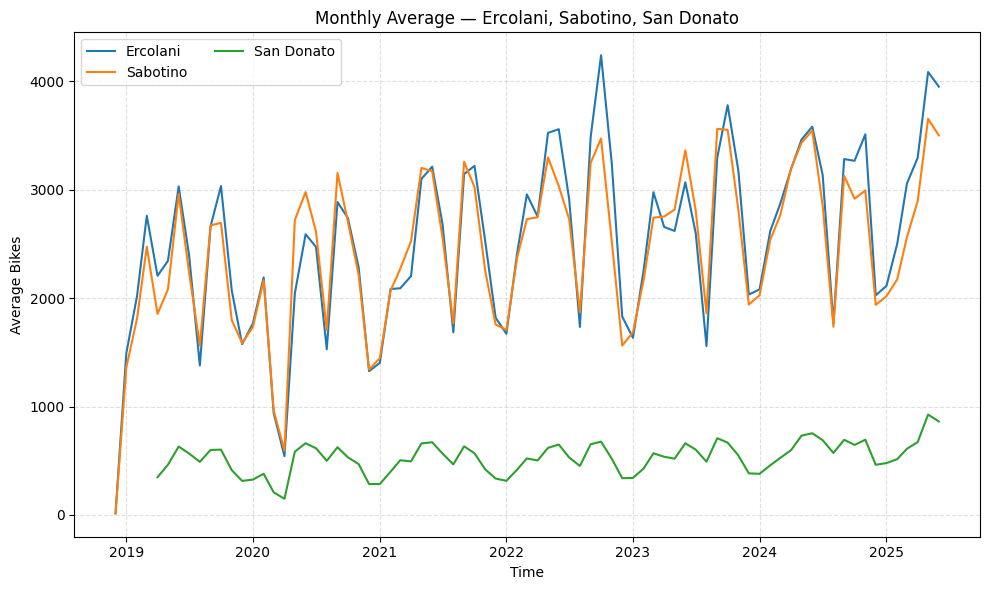

In [20]:
monthly3 = resample_mean(df3, 'MS')
piv = (monthly3.pivot(index='timestamp', columns='station', values='avg')
                .sort_index())
plot_multiline(piv, title='Monthly Average — Ercolani, Sabotino, San Donato')

## Index 100 — growth vs base

**What this shows:** the **relative growth** of the three station averaged over time, normalized so the **first available period = 100**. This focuses on change rather than absolute volumes.

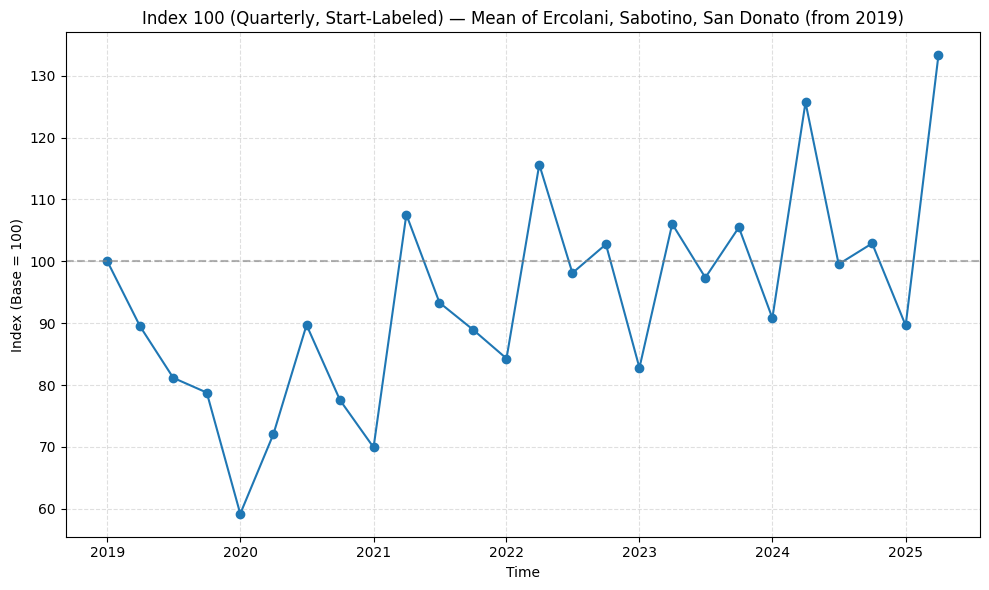

In [21]:
quarterly3 = resample_mean(df3, 'QS')

# Average across the three stations per quarter
avg_quarterly = (
    quarterly3.groupby('timestamp')['avg']
              .mean()
              .sort_index()
)

# filter 2019 onwards
avg_quarterly = avg_quarterly[avg_quarterly.index >= pd.Timestamp('2019-01-01')]

# Normalize so the first available quarter (2019 Q1) = 100
base = avg_quarterly.iloc[0]
idx_series = (avg_quarterly / base) * 100.0

# Plot a single Index 100 line
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(idx_series.index, idx_series.values, marker='o')

ax.axhline(100, linestyle='--', color='gray', alpha=0.6)
ax.set_title('Index 100 (Quarterly, Start-Labeled) — Mean of Ercolani, Sabotino, San Donato (from 2019)')
ax.set_xlabel('Time')
ax.set_ylabel('Index (Base = 100)')
ax.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
plt.show()

## Other visualization ideas

- **Day-of-week pattern**: highlight commute vs weekend differences.
- **Rolling mean (30/90 days)**: smooth out short‑term volatility to emphasize trends.
- **Share of total**: each station’s proportion of total city counts over time.

### Example: Day‑of‑week pattern (3 stations)

**Why:** helps understand weekly rhythms; useful for planning and anomaly detection.

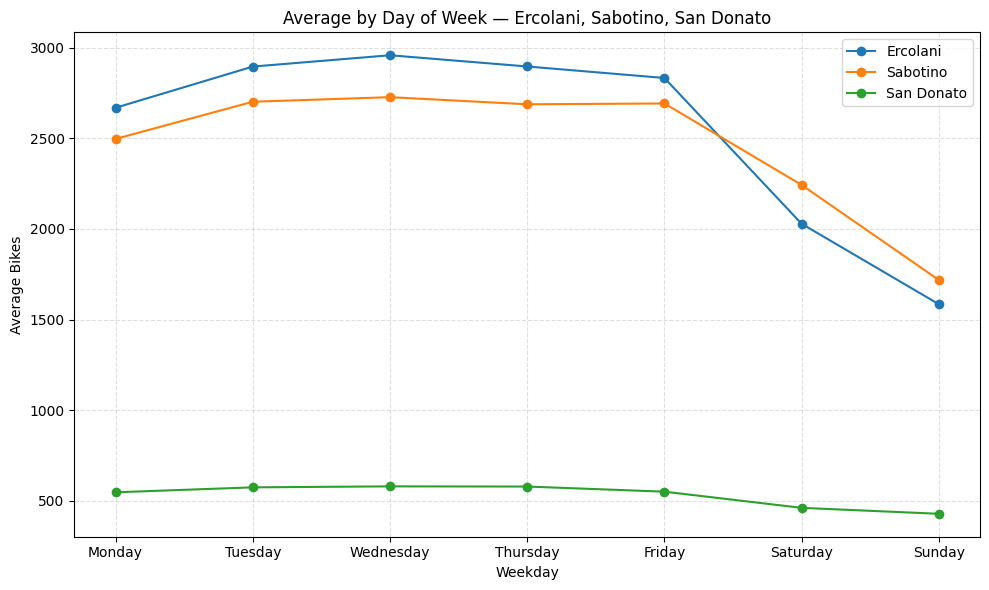

In [ ]:
tmp = df3.copy()
tmp['weekday'] = tmp['timestamp'].dt.day_name()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

agg = (tmp.groupby(['station','weekday'])['count']
         .mean()
         .rename('avg')
         .reset_index())

piv = agg.pivot(index='weekday', columns='station', values='avg').reindex(order)

fig, ax = plt.subplots(figsize=(10, 6))
for col in piv.columns:
    ax.plot(piv.index, piv[col], marker='o', label=col)
ax.set_title('Average by Day of Week — Ercolani, Sabotino, San Donato')
ax.set_xlabel('Weekday')
ax.set_ylabel('Average Bikes')
ax.legend(loc='best')
ax.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
plt.show()

## Semiannual 3 stations Average (single line)

**Why:** semiannual averages (H1/H2) give a concise overview of medium‑term change and help compare patterns across years with reduced noise. Average between the 3 station provides a more concise data too

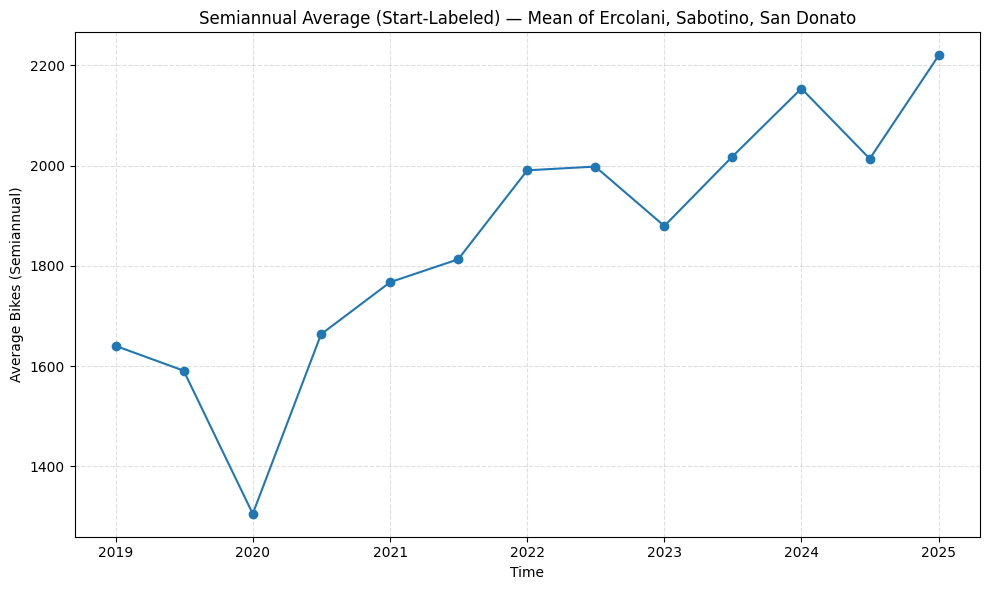

In [22]:
tmp = df3.copy()
tmp['year']  = tmp['timestamp'].dt.year
tmp['half']  = np.where(tmp['timestamp'].dt.month <= 6, 1, 2)   # 1=H1 (Jan–Jun), 2=H2 (Jul–Dec)

half = (
    tmp.groupby(['station', 'year', 'half'])['count']
       .mean()
       .rename('avg')
       .reset_index()
)

start_month = np.where(half['half'] == 1, 1, 7)
half['period_start'] = pd.to_datetime(
    half['year'].astype(str) + '-' + pd.Series(start_month, index=half.index).astype(str) + '-01',
    format='%Y-%m-%d'
)

# Filter 2019 onward
half = half[half['year'] >= 2019].copy()

# Average across the three stations for each semiannual period
avg3 = (
    half.groupby('period_start')['avg']
        .mean()
        .sort_index()
)

# Plot a single line representing the mean of the three stations
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(avg3.index, avg3.values, marker='o')

ax.set_title('Semiannual Average (Start-Labeled) — Mean of Ercolani, Sabotino, San Donato')
ax.set_xlabel('Time')
ax.set_ylabel('Average Bikes (Semiannual)')
ax.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
plt.show()


# 3 - Car Traffic
In this section we manipulate and visualize data regarding car traffic

In [26]:
from SPARQLWrapper import SPARQLWrapper, JSON
import rdflib as rdf
import pandas as pd
import pprint
import re
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import folium
from branca.colormap import LinearColormap
import unicodedata
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
ds2022 = pd.read_csv(filepath_or_buffer="./rilevazione-flusso-veicoli-tramite-spire-anno-2022.csv", sep=";")

FileNotFoundError: [Errno 2] No such file or directory: '../data/rilevazione-flusso-veicoli-tramite-spire-anno-2022.csv'

In [ ]:
pprint.pprint(ds2022.head(4))

         data   codice spira  00:00-01:00  01:00-02:00  02:00-03:00  \
0  2022-10-02  3.96 3.88 2 1          270          150          112   
1  2022-10-02   4.2 4.48 2 1          234          159          110   
2  2022-10-02   4.4 4.48 6 1          214          156          100   
3  2022-10-02  4.6 0.127 8 1           86           53           41   

   03:00-04:00  04:00-05:00  05:00-06:00  06:00-07:00  07:00-08:00  ...  \
0           76           66           76          141          192  ...   
1           74           75          104          157          137  ...   
2           56           40           55           73          113  ...   
3           18           26           37           99           52  ...   

     ordinanza  stato  codimpsem  direzione  angolo  longitudine  latitudine  \
0  4000/343434      A        248         SO   147.0    11.371840   44.511646   
1  4000/343434      A        400        NaN    85.0    11.383961   44.493397   
2  4000/343434      A       

In [ ]:
# HEATMAP CREATION

def normalize_name(s):
    s = str(s).lower().strip()
    s = unicodedata.normalize('NFKD', s)
    return s

files = [
    'rilevazione-autoveicoli-tramite-spire-anno-2019.csv',
    'rilevazione-autoveicoli-tramite-spire-anno-2020.csv',
    'rilevazione-autoveicoli-tramite-spire-anno-2021.csv',
    'rilevazione-flusso-veicoli-tramite-spire-anno-2022.csv',
    'rilevazione-flusso-veicoli-tramite-spire-anno-2023.csv',
    'rilevazione-flusso-veicoli-tramite-spire-anno-2024.csv',
    'rilevazione-flusso-veicoli-tramite-spire-anno-2025.csv'
]

for file in files:
    ds_geo = pd.read_csv(file, sep=';', parse_dates=['data'])
    year = file[-8:-4]
    hour_cols = [c for c in ds_geo.columns if ':' in c]
    ds_geo['daily_total'] = ds_geo[hour_cols].sum(axis=1)
    spire_avg = ds_geo.groupby('codice spira')['daily_total'].mean().reset_index().rename(columns={'daily_total':'value'})

    road_avg = ds_geo[['codice spira', 'Nome via']].drop_duplicates().merge(spire_avg, on='codice spira')
    road_avg = road_avg.dropna()
    road_avg['stname'] = road_avg['Nome via'].apply(normalize_name)
    road_avg = road_avg.groupby('stname')['value'].mean().reset_index()

    G = ox.graph_from_place("Bologna, Italy", network_type="drive")
    streets = ox.graph_to_gdfs(G, nodes=False, edges=True)
    streets = streets[['name','geometry']].dropna(subset=['name'])
    streets_max_precision = streets.explode('name').rename(columns={'name':'stname'})
    streets_max_precision['stname'] = streets_max_precision['stname'].apply(normalize_name)

    weighted_streets = streets_max_precision.merge(road_avg, on='stname', how='left')

    vals = weighted_streets['value'].dropna()
    if vals.empty:
        min_cars, max_cars = 0.0, 1.0
    else:
        min_cars, max_cars = float(vals.min()), float(vals.max())
        if min_cars == max_cars:
            min_cars = 0.0

    legend = LinearColormap(
        colors=['white', 'yellow', 'red'],
        index=[min_cars, (min_cars + max_cars) / 2.0, max_cars],
        vmin=min_cars, vmax=max_cars, text_color='black'
    )
    legend.caption = f'Average traffic in the year {year}'

    def style_for_map(feature):
        val = feature['properties'].get('value', None)
        if val is None or (isinstance(val, float) and np.isnan(val)):
            color = "#717171"
        else:
            try:
                color = legend(float(val))
            except Exception:
                color = "#717171"
        return {
            'color': color,
            'weight': 3,
            'opacity': 0.9
        }

    m = folium.Map(
        location=[44.4949, 11.3426],
        zoom_start=13,
        tiles='cartodbpositron',
        max_bounds=True,
        min_zoom=12,
        max_zoom=18
    )

    folium.GeoJson(
        data=weighted_streets.__geo_interface__,
        name=f'Average traffic in the year {year}',
        style_function=style_for_map,
        tooltip=folium.GeoJsonTooltip(
            fields=['stname', 'value'],
            aliases=['Street:', 'Cars/day:'],
            localize=True
        )
    ).add_to(m)


    bounds = weighted_streets.total_bounds 
    m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])

    m.add_child(legend)
    out_path = f'./maps/heatmapVie{year}.html'
    m.save(out_path)
    print(f"saved {out_path}")


saved ./maps/heatmapVie2019.html
saved ./maps/heatmapVie2020.html
saved ./maps/heatmapVie2021.html
saved ./maps/heatmapVie2022.html
saved ./maps/heatmapVie2023.html
saved ./maps/heatmapVie2024.html
saved ./maps/heatmapVie2025.html


In [ ]:
# DATA CLEANING FOR REPORTS OF CAR TRAFFIC (SEMI-ANNUALY)

ore = [
    "00:00-01:00", "01:00-02:00", "02:00-03:00", "03:00-04:00", "04:00-05:00", "05:00-06:00",
    "06:00-07:00", "07:00-08:00", "08:00-09:00", "09:00-10:00", "10:00-11:00", "11:00-12:00",
    "12:00-13:00", "13:00-14:00", "14:00-15:00", "15:00-16:00", "16:00-17:00", "17:00-18:00",
    "18:00-19:00", "19:00-20:00", "20:00-21:00", "21:00-22:00", "22:00-23:00", "23:00-24:00"
]
files = ['rilevazione-autoveicoli-tramite-spire-anno-2019.csv', 'rilevazione-autoveicoli-tramite-spire-anno-2020.csv','rilevazione-autoveicoli-tramite-spire-anno-2021.csv','rilevazione-flusso-veicoli-tramite-spire-anno-2022.csv','rilevazione-flusso-veicoli-tramite-spire-anno-2023.csv','rilevazione-flusso-veicoli-tramite-spire-anno-2024.csv','rilevazione-flusso-veicoli-tramite-spire-anno-2025.csv']

def period_division(row):
    row["year"] = row["month"][0:4]

    if re.search(r"-0[1-6]", row["month"]):
        row["period"] = "1"
        row["label"] = row["year"]
        row["month"] = row["year"]+"-06"
    elif re.search(r"-0[7-9]|-1[0-2]", row["month"]):
        row["period"] = "2"
        row["label"] = ""
        row["month"] = row["year"]+"-09"
    row["order"] = row["year"]+row["period"]
    return row

ds_complete = pd.DataFrame()

for ds in files:
    ds_current = pd.read_csv(ds, sep=";", parse_dates=["data"])
    ds_current["tot_day"] = ds_current[ore].sum(1)
    ds_current["month"] = ds_current["data"].dt.to_period("M").astype(str)
    ds_ordered = ds_current.groupby(["month", "Nome via"])["tot_day"].mean().reset_index()
    #print(ds_ordered.head(5))
    months = [ "-01", "-02", "-03", "-04", "-05", "-06","-07", "-08", "-09","-10", "-11", "-12"]
        
    ds_periods = ds_ordered.apply(period_division, axis=1)
    #ds_periods = ds_periods.drop(columns = ["month"])
    ds_final = ds_periods.groupby(["Nome via", "period", "year", "order", "label", "month"])["tot_day"].mean().reset_index()
    ds_final = ds_final.dropna()
    ds_complete = pd.concat([ds_complete, ds_final], ignore_index = True)


In [ ]:
# PREPARING FOR NORMALIZING STREET NAMES TO MATCH HEATMAPS


def normalize_name_streets(row):
    #print(row)
    s = row["stname"]
    s = s.lower().strip()
    s = unicodedata.normalize('NFKD', s)
    row["stname"] = s
    return row
#print(ds_complete.head(5))
ds_complete2 = ds_complete.rename(columns={"Nome via": "stname"})
#print(ds_newname[["stname"]])
#print(ds_complete2.head(5))
ds_complete2 = ds_complete2.apply(normalize_name_streets, axis=1)
#print(ds_complete2.head(5))

G = ox.graph_from_place("Bologna, Italy", network_type="drive")
streets = ox.graph_to_gdfs(G, nodes=False, edges=True)
streets = streets[['name','geometry']].dropna(subset=['name'])
streets_max_precision = streets.explode('name').rename(columns={'name':'stname'})
streets_max_precision = streets_max_precision.apply(normalize_name_streets, axis=1)
#print(streets_max_precision)

weighted_streets2 = streets_max_precision[['stname']].merge(ds_complete2, on='stname', how='right')
data_for_graph = weighted_streets2.drop_duplicates()

In [ ]:
print(data_for_graph.head(5))
print(len(data_for_graph))

                         stname period  year  order label    month  \
0       largo bartolo nigrisoli      1  2019  20191  2019  2019-06   
9       largo bartolo nigrisoli      2  2019  20192        2019-09   
18  largo card. giacomo lercaro      1  2019  20191  2019  2019-06   
19  largo card. giacomo lercaro      2  2019  20192        2019-09   
20         largo mariele ventre      1  2019  20191  2019  2019-06   

        tot_day  
0   1438.485868  
9   1236.106004  
18  2683.500000  
19  2415.586380  
20  8949.023797  
3925


In [ ]:
data_for_graph.to_csv("flusso_per_html_veicoli_per_semestri.csv")

In [ ]:
# TESTING

ds_complete = ds_complete.rename(columns={"Nome via":"NomeVia"})
ds_viz = ds_complete.query('NomeVia == "VIA ANTONIO LABRIOLA"').reset_index(drop=True)
#ds_viz.sort_values(["year", "period"])


In [ ]:
print(ds_viz)
print(len(ds_viz))

                 NomeVia period  year  order label    month      tot_day
0   VIA ANTONIO LABRIOLA      1  2022  20221  2022  2022-03  1146.470430
1   VIA ANTONIO LABRIOLA      2  2022  20222        2022-06  1165.074194
2   VIA ANTONIO LABRIOLA      3  2022  20223        2022-09   878.489606
3   VIA ANTONIO LABRIOLA      4  2022  20224        2022-12  1210.338351
4   VIA ANTONIO LABRIOLA      1  2023  20231  2023  2023-03  1177.572094
5   VIA ANTONIO LABRIOLA      2  2023  20232        2023-06  1155.637091
6   VIA ANTONIO LABRIOLA      3  2023  20233        2023-09   903.043011
7   VIA ANTONIO LABRIOLA      4  2023  20234        2023-12  1204.244444
8   VIA ANTONIO LABRIOLA      1  2024  20241  2024  2024-03  1167.788654
9   VIA ANTONIO LABRIOLA      2  2024  20242        2024-06  1113.692115
10  VIA ANTONIO LABRIOLA      3  2024  20243        2024-09   743.532975
11  VIA ANTONIO LABRIOLA      4  2024  20244        2024-12  1145.811470
12  VIA ANTONIO LABRIOLA      1  2025  20251  2025 

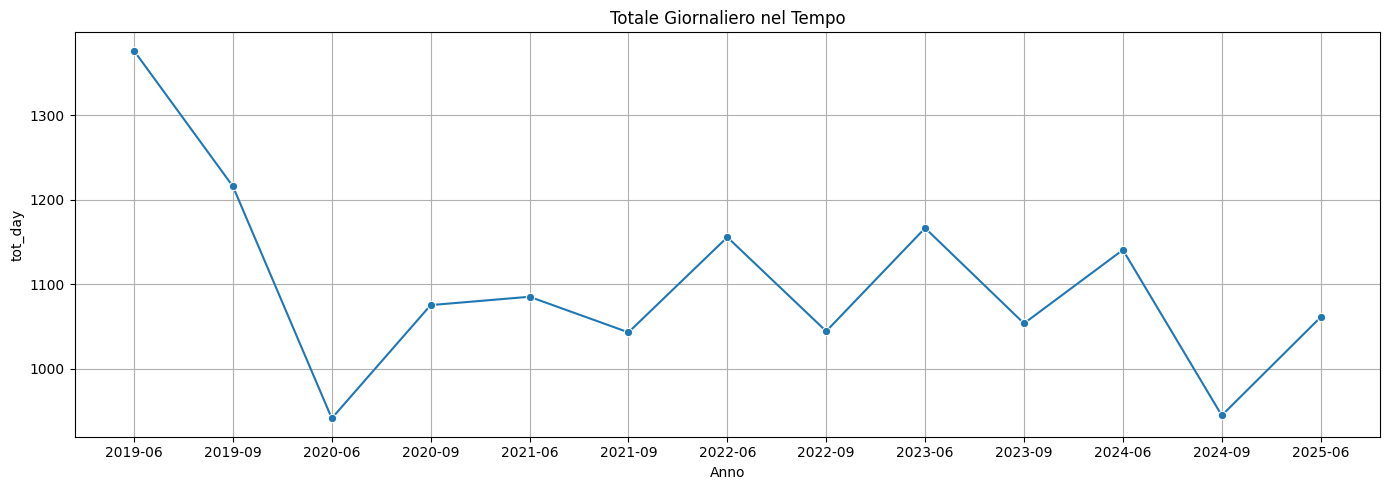

In [ ]:
# TESTING FINAL VIZUALIZATION

plt.figure(figsize=(14, 5))
sns.lineplot(data=ds_viz, x="order", y="tot_day", marker="o")

plt.xticks(ticks=range(len(ds_viz)), labels=ds_viz["month"], rotation=0)

plt.title("Totale Giornaliero nel Tempo")
plt.xlabel("Anno")
plt.ylabel("tot_day")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
print (len(ds_ordered["Nome via"].unique()))

318


# 4 - 30 vs non30 Zones
In this section we compare synchronically the traffic data (for both cars and bikes) for streets affected by Città 30 limits and streets unaffected.

In [ ]:
# PREPARING 30-VS-NON-30 GRAPH: BIKES

bike = pd.read_csv("./bike-trimmed.csv")
bike["data"] = pd.to_datetime(bike["data"])
print(bike.head(1))

bike_useful = bike[bike["data"].dt.year == 2024]
bike_grouped = (
    bike_useful.groupby("colonnina", as_index=False)
    .agg(
        totale_medio=("totale", "mean"),
        VEL2024=("VEL2024", "first")
    )
)

print(bike_grouped)

In [ ]:
# DATA CLEANING

bike_col = list(bike["colonnina"].unique())
bike_col.append("Laura Bassi")               
bike_col.remove("Laura_Bassi")   
print(bike_col)

In [ ]:
# DATA CLEANING FOR MATCHING DATAFRAMES (CARS AND BIKES)

bike_col_lower = [col.lower() for col in bike_col]

def find_streets(row):
    st = row["stname"].lower()
    for col in bike_col_lower:
        if col in st:
            return True
    return False

data_for_graph["has_colonnina"] = data_for_graph.apply(find_streets, axis=1)

df_filtrato = data_for_graph[data_for_graph["has_colonnina"]].copy()

df_filtrato = df_filtrato.drop(columns=["has_colonnina"])

C:\Users\nicco\AppData\Local\Temp\ipykernel_32568\2214452767.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_for_graph["has_colonnina"] = data_for_graph.apply(find_streets, axis=1)


In [ ]:
print(df_filtrato)

In [ ]:
# MERGING DFs

bike_col_lower = [col.lower() for col in bike_col]

def match_colonnina(stname):
    stname_lower = stname.lower()
    for col in bike_col_lower:
        if col in stname_lower:
            return col
    return None

df_filtrato["colonnina"] = df_filtrato["stname"].apply(match_colonnina)
bike_grouped["colonnina"] = bike_grouped["colonnina"].apply(match_colonnina)


df_filtrato = df_filtrato[df_filtrato["colonnina"].notna()]
df_finale = df_filtrato.merge(bike_grouped, on="colonnina", how="left")

df_finale = df_finale.dropna()


print(df_finale)

In [ ]:
# DROPPING UNUSED COLUMNS

df_car_bikes = df_finale[["tot_day", "totale_medio", "VEL2024"]]
df_car_bikes = df_car_bikes.rename(columns={"tot_day":"cars", "totale_medio":"bikes"})
print(df_car_bikes)

In [ ]:
# 30-ONLY DATA

df_30 = df_car_bikes.query("VEL2024 <= 30")
print(df_30)
df_30.to_csv("vie30.csv")

            cars       bikes  VEL2024
0    8978.200624  659.944444     30.0
1    7941.901694  659.944444     30.0
10   1574.936034  842.538251     30.0
11   1062.984588  842.538251     30.0
12   9873.559085  872.335294     30.0
..           ...         ...      ...
180  8374.265406  872.335294     30.0
181  8375.721716  804.878788     30.0
183  5134.526324  900.606061     30.0
185  5477.218430  600.704918     30.0
186  6922.747505  614.090909     30.0

[85 rows x 3 columns]


In [ ]:
# 50-OR-ABOVE DATA

df_non30 = df_car_bikes.query("VEL2024 > 30")
print(df_non30)
df_non30.to_csv("vie-non30.csv")

             cars        bikes  VEL2024
2     9823.837106   337.212121     50.0
3     8834.397696   337.212121     50.0
4     8172.529458   337.212121     50.0
5     8698.446302   337.212121     50.0
6     5294.515076   402.375000     50.0
..            ...          ...      ...
175   9820.428919   337.212121     50.0
176   3166.007844   337.212121     50.0
177   4127.183097   402.375000     50.0
184  17330.470302  2752.983607     50.0
188   9147.246640  2896.150273     50.0

[65 rows x 3 columns]


In [ ]:
# AVERAGES FOR EACH GROUP

d_30_cars_means = df_30["cars"].mean()
d_30_bikes_means = df_30["bikes"].mean()
d_non30_cars_means = df_non30["cars"].mean()
d_non30_bikes_means = df_non30["bikes"].mean()
df_30vsnon30 = pd.DataFrame(data={"cars (limit 30)": d_30_cars_means, "bikes (limit 30)": d_30_bikes_means, "cars (limit above 30)": d_non30_cars_means, "bikes (limit above 30)": d_non30_bikes_means}, index=[0])
print(df_30vsnon30)
df_30vsnon30.to_csv("df_30vsnon30.csv")

   cars (limit 30)  bikes (limit 30)  cars (limit above 30)  \
0      6139.703162        767.435919            9381.779277   

   bikes (limit above 30)  
0             1345.186624  


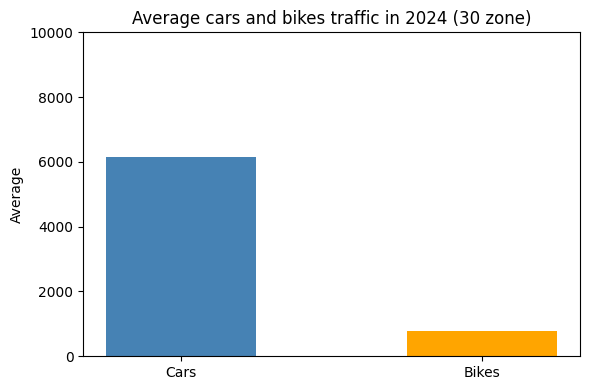

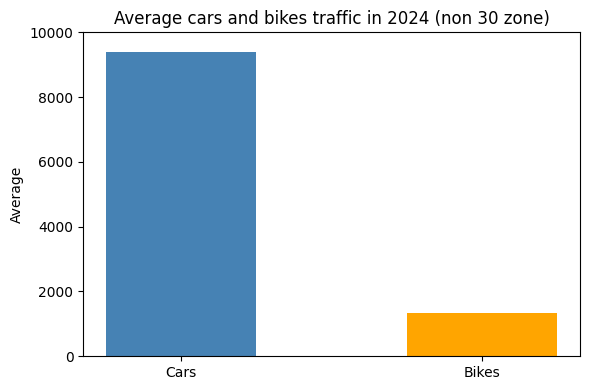

In [ ]:
# TESTING VISUALIZATION

for df in [df_30, df_non30]:
    cars_mean = df["cars"].mean()
    bikes_mean = df["bikes"].mean()

    # Preparo i dati per il grafico
    categorie = ["Cars", "Bikes"]
    valori = [cars_mean, bikes_mean]

    plt.figure(figsize=(6, 4))
    plt.bar(categorie, valori, color=["steelblue", "orange"], width=0.5)
    plt.ylim(top=10000)
    plt.ylabel("Average")
    if df["VEL2024"].iloc[0] == 30.0:
       plt.title("Average cars and bikes traffic in 2024 (30 zone)")
    else:
        plt.title("Average cars and bikes traffic in 2024 (non 30 zone)")
    plt.tight_layout()
    plt.show()

# 5 - Air Quality
In this section we focus on data about air quality in Bologna, with the intent to investigate correlations with Città 30

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# import data
# data before 2025
old_data = pd.read_csv("original_data/dati-centraline-bologna-storico.csv", delimiter=";")
# 2025 data
new_data = pd.read_csv(
    "original_data/centraline-qualita-aria.csv", delimiter=";"
)

# process the 2 CSV to make them compatible
new_data = pd.read_csv("original_data/centraline-qualita-aria.csv", delimiter=";")
new_data = new_data.rename(
    columns={"reftime": "time", "agente_atm": "gas", "stazione": "station"}
)
new_data = new_data.drop(columns=["_id"])
new_data["gas"] = new_data["gas"].str.upper()
station_names_map = {
    "GIARDINI MARGHERITA, BOLOGNA VIALE BOTTONELLI": "GIARDINI MARGHERITA",
    "VIA CHIARINI, BOLOGNA VIA CHIARINI": "VIA CHIARINI",
    "PORTA SAN FELICE, BOLOGNA PIAZZA DI PORTA SAN FELICE": "PORTA SAN FELICE",
}
new_data["station"] = new_data["station"].map(station_names_map)

old_data = old_data.rename(
    columns={
        "DATA_INIZIO": "time",
        "AGENTE": "gas",
        "COD_STAZ": "station",
        "VALORE": "value",
    }
)
old_data = old_data.drop(columns=["DATA_FINE", "UM"])

# check if the gases are the same
print(set(old_data["gas"].unique()) == set(new_data["gas"].unique()))

True


In [ ]:
# concat the 2 CSV
data = pd.concat([old_data, new_data], axis=0, ignore_index=True)

# remove VIA CHIARINI station data
data = data[data["station"] != "VIA CHIARINI"]

# convert data to UTC format Eg: 2016-12-30 23:01:00+00:00
data["time"] = pd.to_datetime(data["time"], utc=True)
data["time"] = pd.to_datetime(data["time"], utc=True)

# remove data before 2019
data = data[data["time"] >= "2019-01-01"]

# order from most recent
data = data.sort_values(by="time", ascending=False)

# create a dictionary where each key is a gas that has as value the dataframe with the gas data
gases = data["gas"].unique()
gases_dict = {gas: data[data["gas"] == gas].copy() for gas in gases}

# not interesting for human health
del gases_dict["NOX (OSSIDI DI AZOTO)"]
del gases_dict["NO (MONOSSIDO DI AZOTO)"]

# which stations measures which gases
for gas, gas_df in gases_dict.items():
    stations = gas_df["station"].unique()
    print(f"{gas}: {', '.join(stations)}")

PM10: GIARDINI MARGHERITA, PORTA SAN FELICE
O3 (OZONO): GIARDINI MARGHERITA
CO (MONOSSIDO DI CARBONIO): PORTA SAN FELICE
NO2 (BIOSSIDO DI AZOTO): PORTA SAN FELICE, GIARDINI MARGHERITA
PM2.5: GIARDINI MARGHERITA, PORTA SAN FELICE
C6H6 (BENZENE): PORTA SAN FELICE


In [ ]:
# for each gas, compute year-&-station means of VALORE
year_station_means = {}

for gas, df_gas in gases_dict.items():
    # extract year and day
    df_gas["year"] = df_gas["time"].dt.year
    df_gas["day"] = df_gas["time"].dt.date

    # compute daily means per station
    day_mean = df_gas.groupby(["day", "station", "year"], as_index=False)[
        "value"
    ].mean()

    # now compute the mean of those daily means **by** year AND station
    year_mean = (
        day_mean.groupby(["year", "station"], as_index=False)["value"]
        .mean()
        .rename(columns={"value": "yearly_mean"})
    )

    # store result
    year_station_means[gas] = year_mean

# Example
year_station_means["O3 (OZONO)"]

,year,station,yearly_mean
0,2019,GIARDINI MARGHERITA,49.865309
1,2020,GIARDINI MARGHERITA,47.033161
2,2021,GIARDINI MARGHERITA,46.641242
3,2022,GIARDINI MARGHERITA,51.190006
4,2023,GIARDINI MARGHERITA,52.364133
5,2024,GIARDINI MARGHERITA,46.974363
6,2025,GIARDINI MARGHERITA,49.180697


In [ ]:
# remove via chiarini because it is not relevant for zone 30 and not enough gases are measured there
for gas, gas_df in year_station_means.items():
    year_station_means[gas] = gas_df[gas_df["station"] != "VIA CHIARINI"]

# eg
year_station_means["NO2 (BIOSSIDO DI AZOTO)"]

,year,station,yearly_mean
0,2019,GIARDINI MARGHERITA,20.489283
1,2019,PORTA SAN FELICE,46.449569
3,2020,GIARDINI MARGHERITA,17.003752
4,2020,PORTA SAN FELICE,38.532610
6,2021,GIARDINI MARGHERITA,16.510233
7,2021,PORTA SAN FELICE,43.320746
9,2022,GIARDINI MARGHERITA,18.390174
10,2022,PORTA SAN FELICE,38.979245
12,2023,GIARDINI MARGHERITA,15.649784
13,2023,PORTA SAN FELICE,42.781264


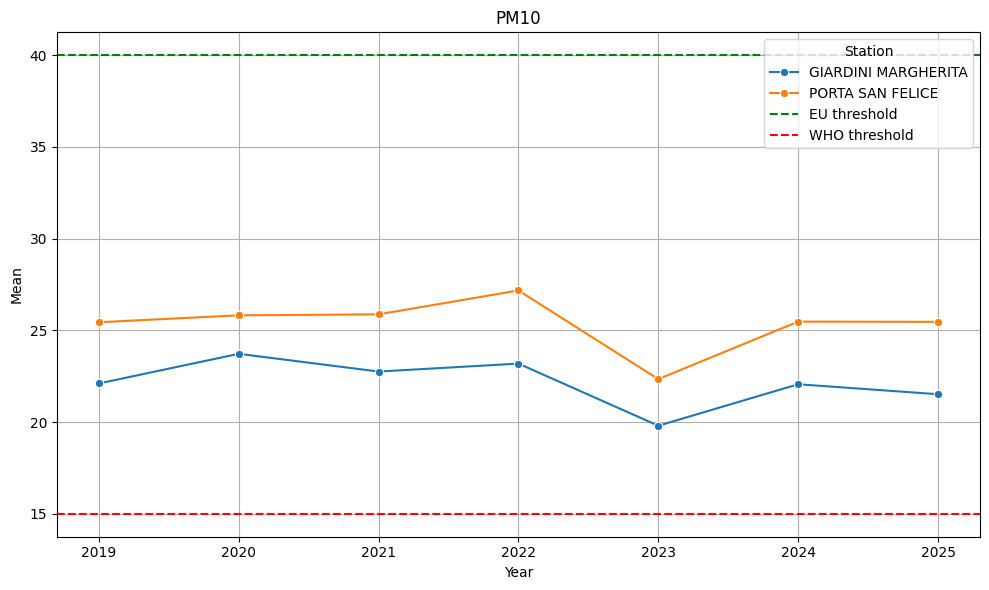

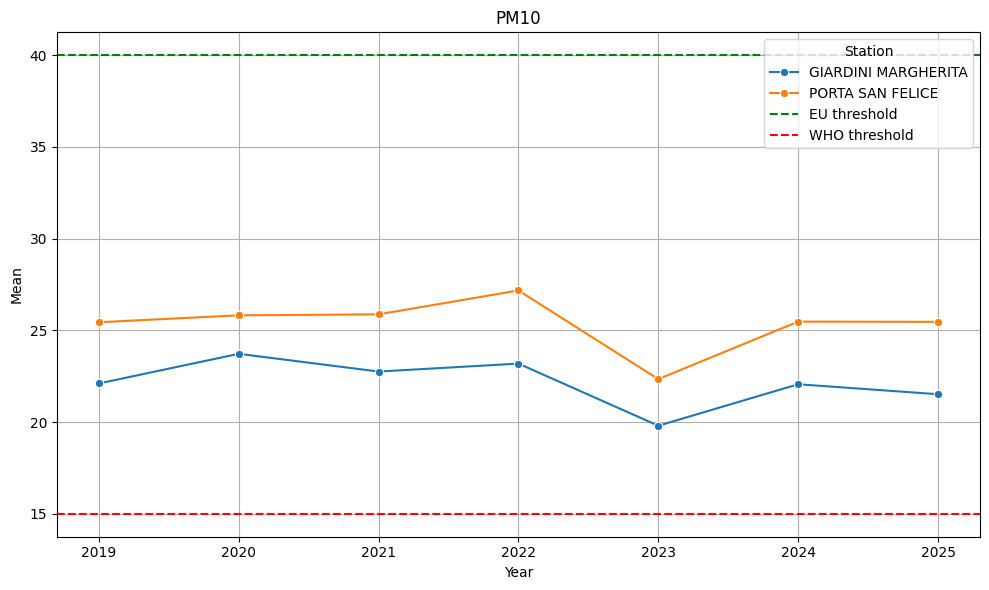

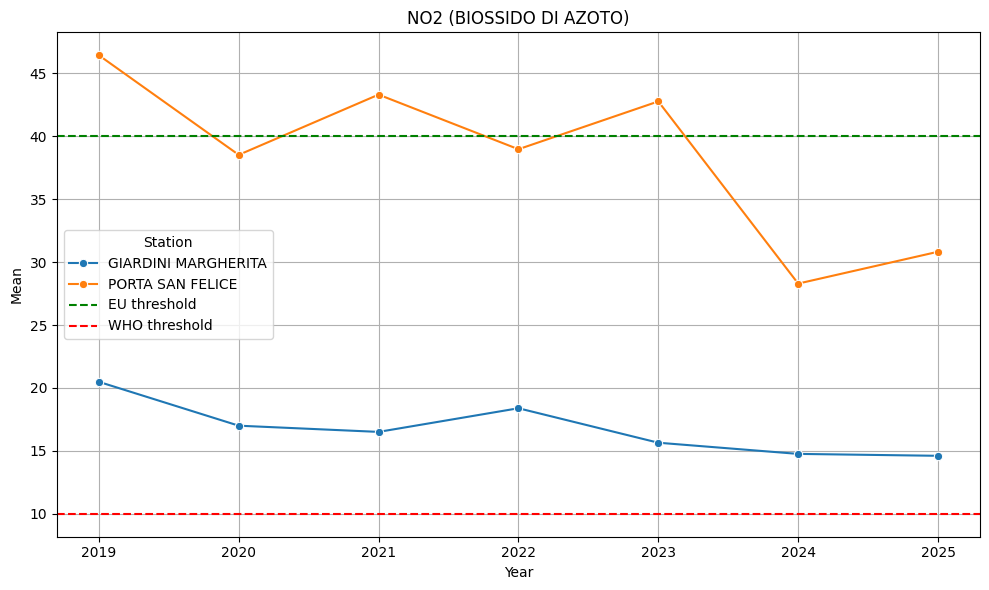

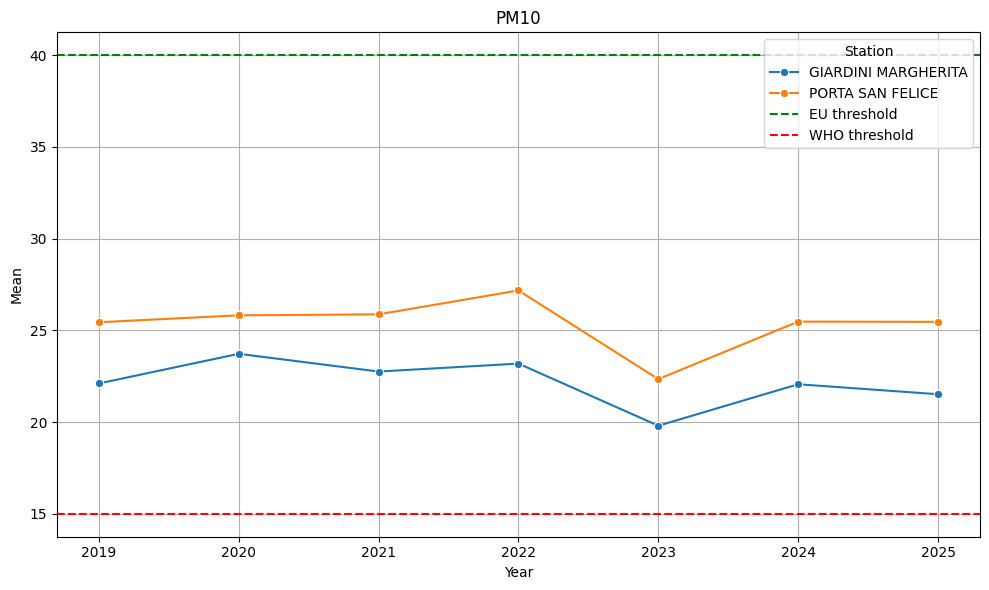

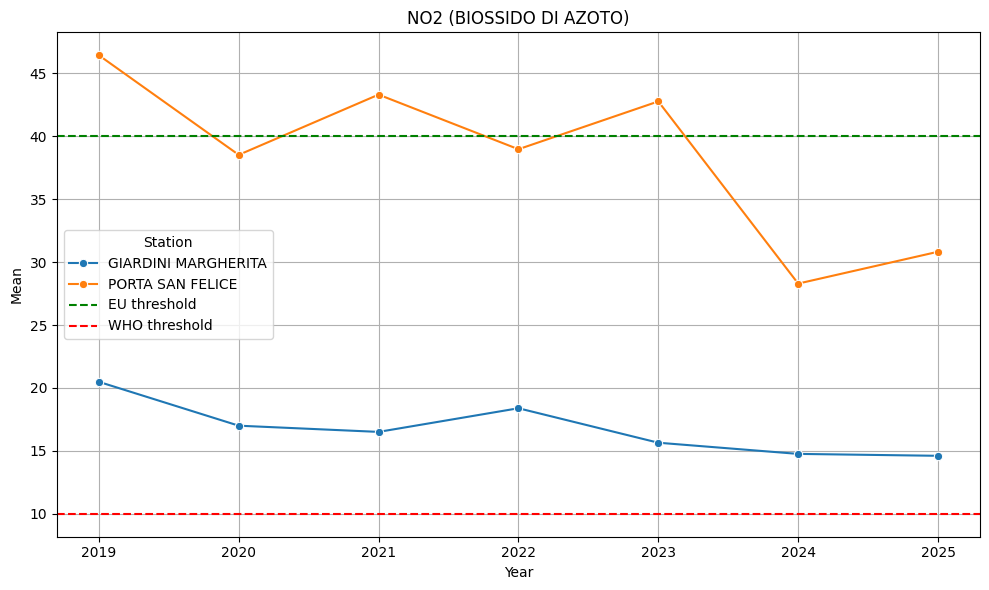

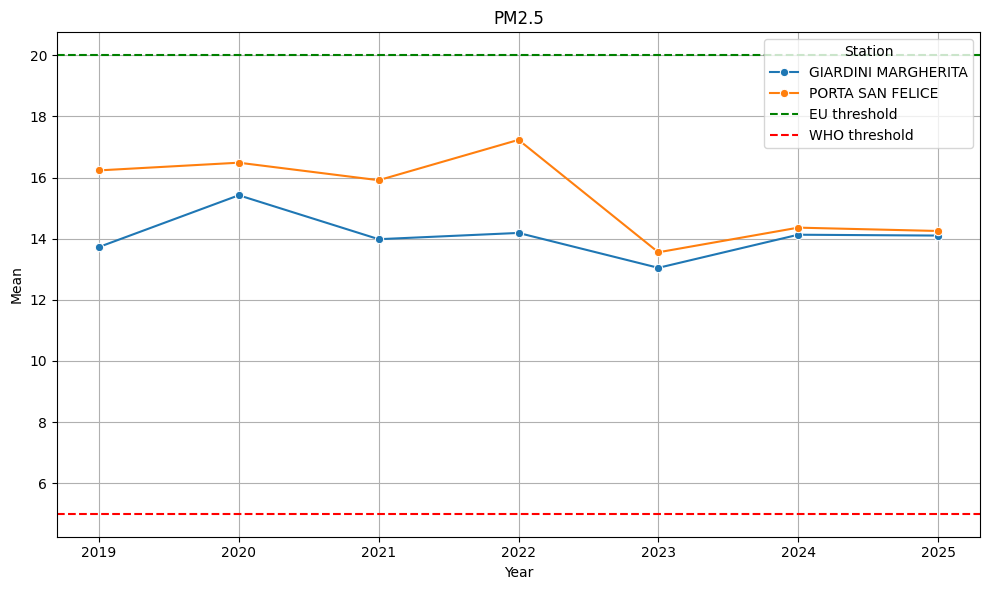

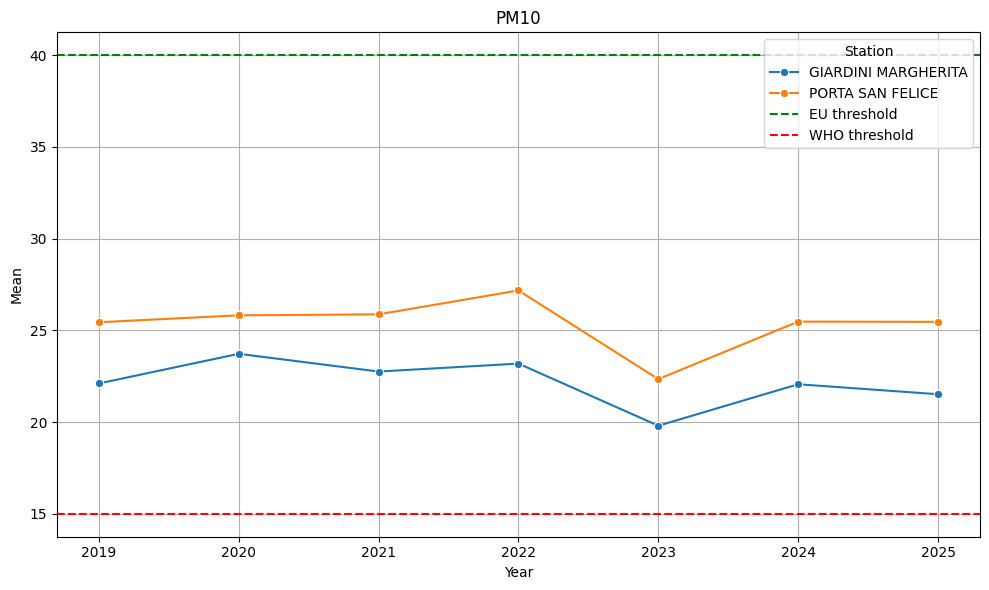

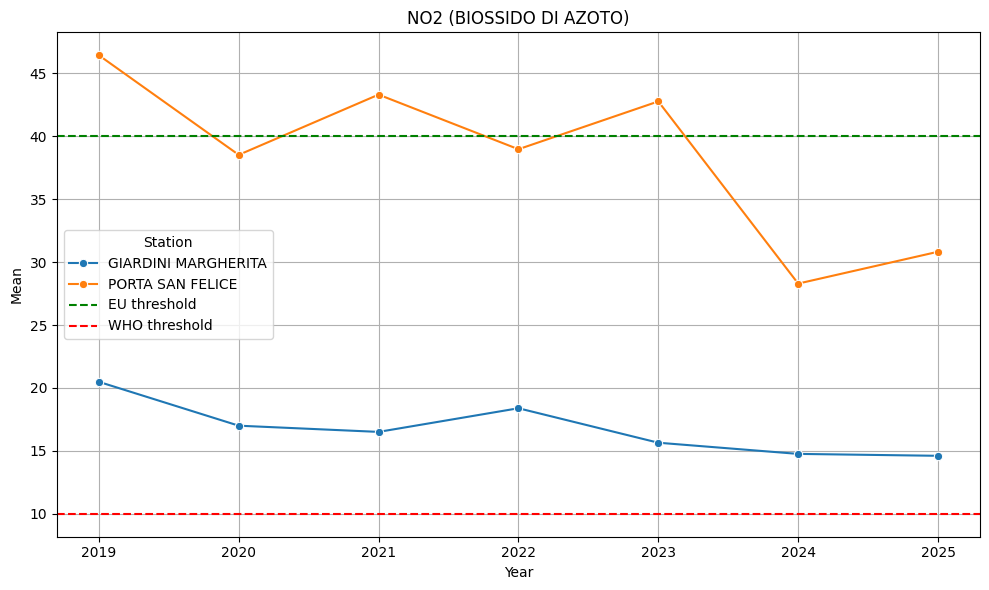

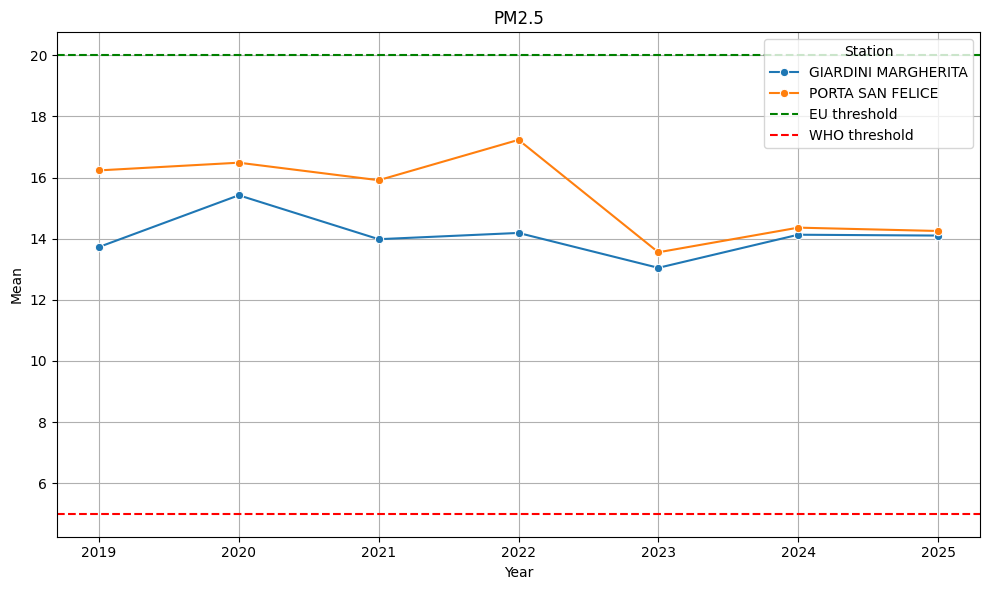

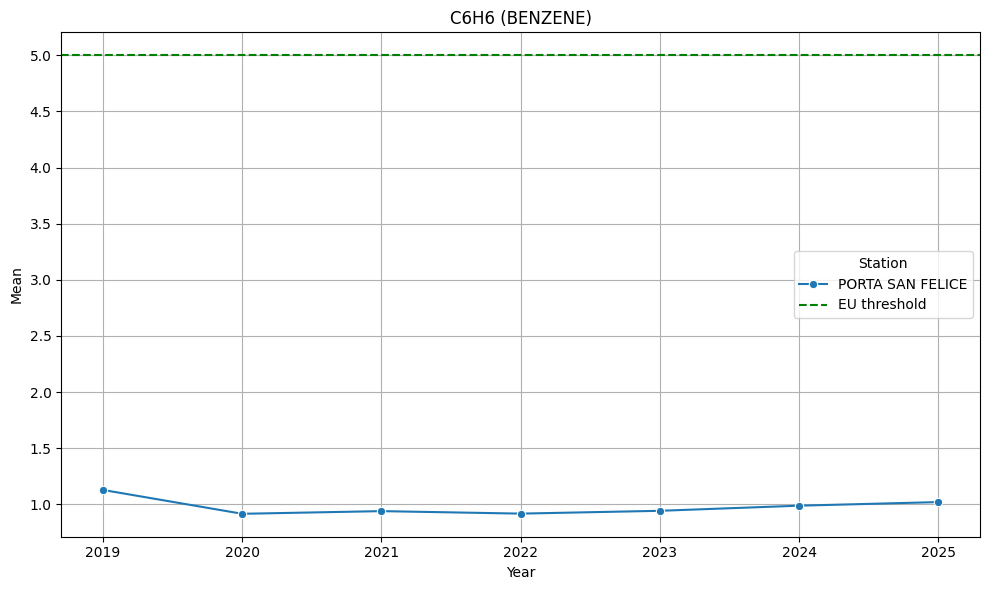

In [ ]:
# plotting time
thresholds = {
    "C6H6 (BENZENE)": {"EU": 5},
    # "O3 (OZONO)": {"EU":}, different way of calculating the threhsold - see later
    # "CO (MONOSSIDO DI CARBONIO)": {"EU":}, different way of calculating the threhsold - see later
    "NO2 (BIOSSIDO DI AZOTO)": {"WHO": 10, "EU": 40},
    "PM2.5": {"WHO": 5, "EU": 20},
    "PM10": {"WHO": 15, "EU": 40},
}

for gas, gas_df in year_station_means.items():

    if gas in thresholds:
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=gas_df, x="year", y="yearly_mean", marker="o", hue="station")

        # Add threshold line
        WHO_THRESHOLD = thresholds.get(gas).get("WHO")
        EU_THRESHOLD = thresholds.get(gas).get("EU")

        if EU_THRESHOLD:
            plt.axhline(
                y=EU_THRESHOLD,
                color="green",
                linestyle="--",
                linewidth=1.5,
                label="EU threshold",
            )

        if WHO_THRESHOLD:
            plt.axhline(
                y=WHO_THRESHOLD,
                color="red",
                linestyle="--",
                linewidth=1.5,
                label="WHO threshold",
            )

        # show every year
        years = sorted(list(gas_df["year"].unique()))
        plt.xticks(ticks=years)

        plt.title(f"{gas}")
        plt.xlabel("Year")
        plt.ylabel("Mean")
        plt.legend(title="Station")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

**OZONE 03**

/var/folders/pn/fjbkbl1119z07xq7zv89lw240000gn/T/ipykernel_1421/4141344662.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(  # treat each station separately


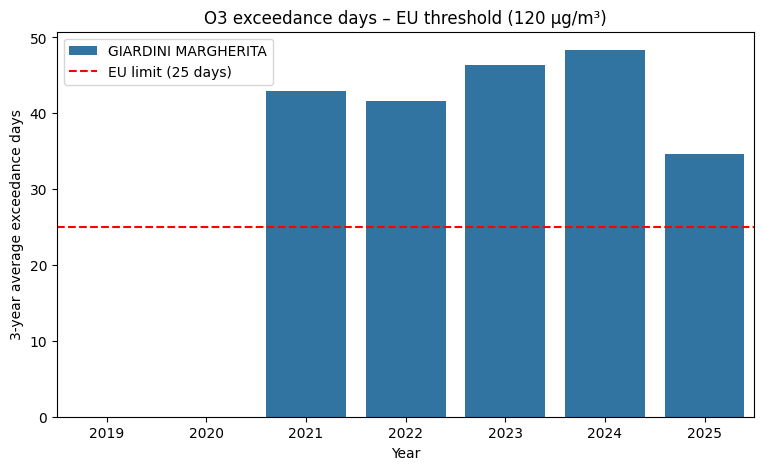

In [ ]:
# OZONE
df_gas = gases_dict["O3 (OZONO)"].copy()

# ensure time is sorted
df_gas = df_gas.sort_values(by=["station", "time"])

# compute 8-hour rolling mean for each station
df_gas["rolling_8h_mean"] = (
    df_gas.groupby("station")["value"]
    .rolling(window=8, min_periods=6)  # allow at least 6 valid hours
    .mean()
    .reset_index(level=0, drop=True)
)

# get which of the 8 hours mean is the highest
df_gas["day"] = df_gas["time"].dt.date

daily_max_8h = (
    df_gas.groupby(["station", "day"], as_index=False)["rolling_8h_mean"]
    .max()
    .rename(columns={"rolling_8h_mean": "max_8h_mean"})
)

# count how many days per year exceed the EU target value (120)
daily_max_8h["year"] = pd.to_datetime(daily_max_8h["day"]).dt.year


# --- EU ---
exceedances_eu = (
    daily_max_8h[daily_max_8h["max_8h_mean"] > 120]
    .groupby(["station", "year"])
    .size()
    .reset_index(name="exceedance_days")
)

exceedances_eu["above_eu_target"] = exceedances_eu["exceedance_days"] > 25
exceedances_eu = exceedances_eu.sort_values(["station", "year"])

three_year_avg_eu = exceedances_eu.groupby(
    "station", group_keys=False
).apply(  # treat each station separately
    lambda g: g.sort_values("year").assign(
        three_year_avg_days=g["exceedance_days"].rolling(window=3, min_periods=3).mean()
    )
)
three_year_avg_eu["standard"] = "EU (120 µg/m³)"

# insert in the data 
year_station_means["O3 (OZONO)"] = {"eu": three_year_avg_eu, "who": None}

plt.figure(figsize=(9, 5))
sns.barplot(
    data=three_year_avg_eu,
    x="year",
    y="three_year_avg_days",
    hue="station",  
    errorbar=None,
)

plt.title("O3 exceedance days – EU threshold (120 µg/m³)")
plt.xlabel("Year")
plt.ylabel("3-year average exceedance days")
plt.axhline(25, color="red", linestyle="--", label="EU limit (25 days)")
plt.legend()
plt.show()

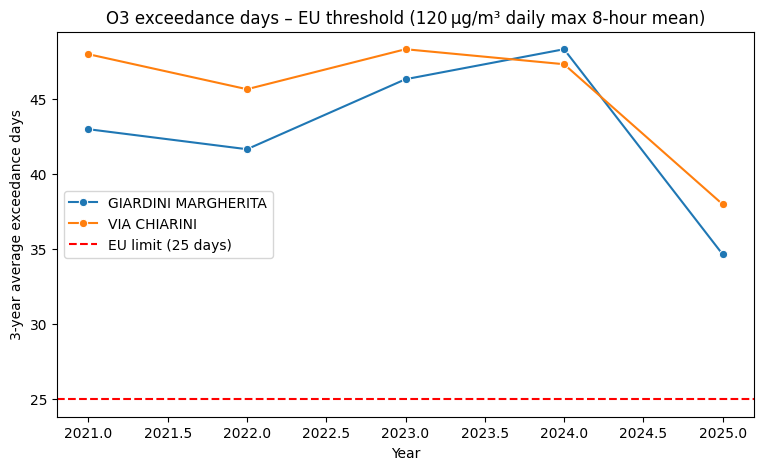

In [ ]:
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=three_year_avg_eu,
    x="year",
    y="three_year_avg_days",
    hue="station",
    marker="o",
    errorbar=None,
)


plt.title("O3 exceedance days – EU threshold (120 µg/m³ daily max 8-hour mean)")
plt.xlabel("Year")
plt.ylabel("3-year average exceedance days")
plt.axhline(25, color="red", linestyle="--", label="EU limit (25 days)")
plt.legend()
plt.show()

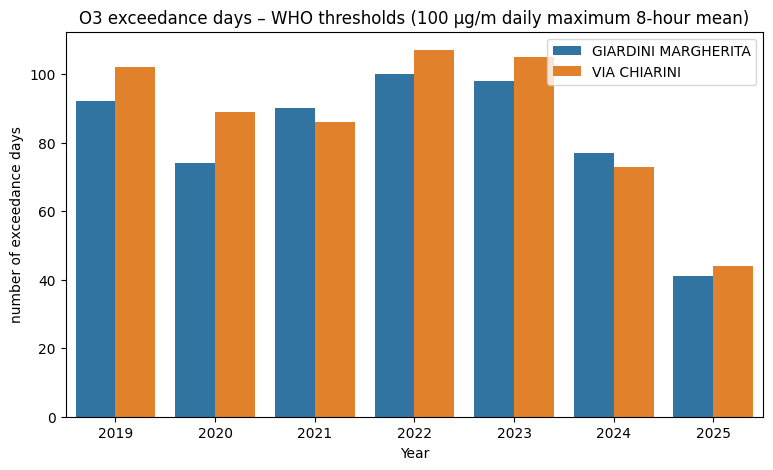

In [ ]:
# --- WHO ---
exceedances_who = (
    daily_max_8h[daily_max_8h["max_8h_mean"] > 100]
    .groupby(["station", "year"])
    .size()
    .reset_index(name="exceedance_days")
)
exceedances_who = exceedances_who.sort_values(["station", "year"])

year_station_means["O3 (OZONO)"]["who"] = exceedances_who

plt.figure(figsize=(9, 5))
sns.barplot(
    data=exceedances_who,
    x="year",
    y="exceedance_days",
    hue="station",  
    errorbar=None,
)

plt.title("O3 exceedance days – WHO thresholds (100 µg/m daily maximum 8-hour mean)")
plt.xlabel("Year")
plt.ylabel("number of exceedance days")
plt.legend()
plt.show()

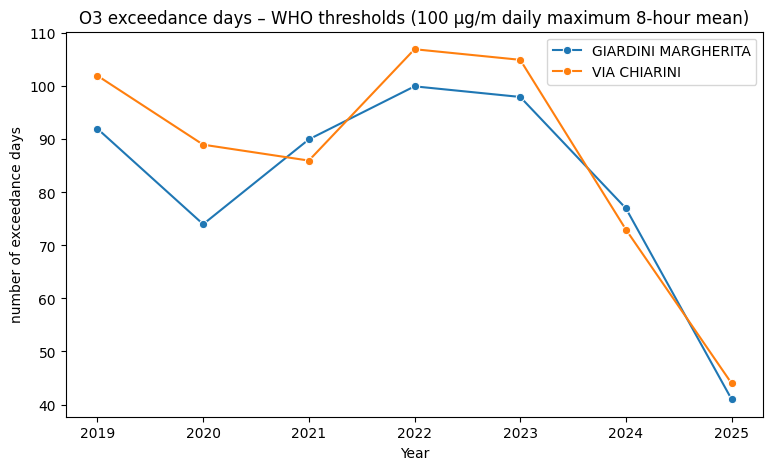

In [ ]:
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=exceedances_who,
    x="year",
    y="exceedance_days",
    hue="station", 
      marker="o",
    errorbar=None,
)

plt.title("O3 exceedance days – WHO thresholds (100 µg/m daily maximum 8-hour mean)")
plt.xlabel("Year")
plt.ylabel("number of exceedance days")
plt.legend()
plt.show()

### CO

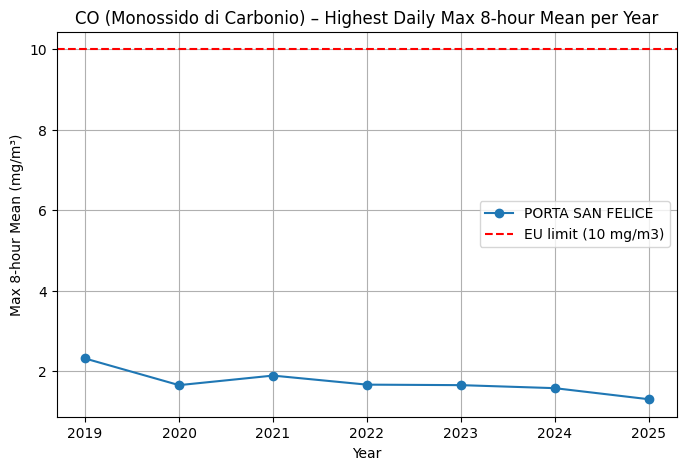

In [ ]:
df_gas = gases_dict["CO (MONOSSIDO DI CARBONIO)"].copy()
df_gas = df_gas.sort_values(by=["station", "time"])

df_gas["rolling_8h_mean"] = (
    df_gas.groupby("station")["value"]
    .rolling(window=8, min_periods=6)
    .mean()
    .reset_index(level=0, drop=True)
)

# get which of the 8 hours mean is the highest
df_gas["day"] = df_gas["time"].dt.date

daily_max_8h = (
    df_gas.groupby(["station", "day"], as_index=False)["rolling_8h_mean"]
    .max()
    .rename(columns={"rolling_8h_mean": "max_8h_mean"})
)

daily_max_8h["year"] = pd.to_datetime(daily_max_8h["day"]).dt.year

yearly_max_8h = (
    daily_max_8h.groupby(["station", "year"], as_index=False)["max_8h_mean"]
    .max()
    .rename(columns={"max_8h_mean": "yearly_max_8h_mean"})
)

year_station_means["CO (MONOSSIDO DI CARBONIO)"] = yearly_max_8h

plt.figure(figsize=(8, 5))

for station, df_station in yearly_max_8h.groupby("station"):
    plt.plot(
        df_station["year"], df_station["yearly_max_8h_mean"], marker="o", label=station
    )

plt.title("CO (Monossido di Carbonio) – Highest Daily Max 8-hour Mean per Year")
plt.xlabel("Year")
plt.ylabel("Max 8-hour Mean (mg/m³)")
plt.axhline(10, color="red", linestyle="--", label="EU limit (10 mg/m3)")
plt.legend()
plt.grid(True)
plt.show()

CO (Monossido di Carbonio – Carbon Monoxide)
Directly emitted by cars, especially petrol and older vehicles. -> so it can be just the use of new vehicles

Save data to use in D3

In [ ]:
import json
from datetime import date

# Convert all timestamps and dates to strings in each DataFrame
def convert_datetime_objects(x):
    if isinstance(x, pd.Timestamp):
        return x.isoformat()
    elif isinstance(x, date):
        return x.isoformat()
    else:
        return x

json_dict = {
    key: df.copy().map(convert_datetime_objects).to_dict(orient="records")
    for key, df in year_station_means.items()
}

# Save to JSON file
with open("gases.json", "w") as f:
    json.dump(json_dict, f, indent=2)  # indent=2 makes it more readable

# 6 Electric Vehicles
In this section we consider the data about EV share in Bologna, in order to ensure that the data about Air Quality ins't affected by a fluctuation in EV usage more than the new regulations on speed limits.

In [ ]:
import pandas as pd

original_data = pd.read_csv("original_data/parco-circolante-veicoli.csv", delimiter=";")
original_data

,Anno,CAP,totale_veicoli,BENZINA,BENZINA E GAS LIQUIDO,BENZINA E METANO,ELETTRICITA,GASOLIO,IBRIDO BENZINA,IBRIDO GASOLIO,...,SRLS,ANZIANITÀ VEICOLO 0 - 1 ANNI,ANZIANITÀ VEICOLO 2 – 3 ANNI,ANZIANITÀ VEICOLO 4 – 5 ANNI,ANZIANITÀ VEICOLO 6 – 7 ANNI,ANZIANITÀ VEICOLO 8 – 9 ANNI,ANZIANITÀ VEICOLO 10 - 12 ANNI,ANZIANITÀ VEICOLO 13 - 15 ANNI,ANZIANITÀ VEICOLO OLTRE 15 ANNI,ANZIANITÀ VEICOLO NON DEFINITO
0,2020,40125,5198,2636,348,176,13.0,1723,264.0,13.0,...,NaN,598.0,663.0,588.0,418.0,431.0,681.0,554.0,1262,3
1,2020,40137,12610,6201,1163,550,22.0,3778,772.0,29.0,...,1.0,1543.0,1758.0,1563.0,1141.0,1089.0,1726.0,1435.0,2352,3
2,2021,40124,4271,2094,332,223,19.0,1258,274.0,38.0,...,6.0,452.0,550.0,522.0,407.0,265.0,537.0,471.0,1064,3
3,2021,40126,5405,2497,481,222,22.0,1724,379.0,33.0,...,1.0,558.0,688.0,627.0,441.0,402.0,689.0,629.0,1366,5
4,2022,40121,4143,1813,321,163,34.0,1354,349.0,55.0,...,19.0,471.0,513.0,530.0,410.0,285.0,397.0,447.0,1084,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2023,40126,5381,2425,473,207,43.0,1534,580.0,73.0,...,9.0,562.0,550.0,615.0,563.0,394.0,552.0,578.0,1562,5
116,2023,40136,5330,2432,300,131,108.0,1493,748.0,86.0,...,2.0,550.0,687.0,733.0,615.0,438.0,490.0,487.0,1327,3
117,2023,40138,19746,7782,2211,919,324.0,5722,2102.0,432.0,...,58.0,2480.0,2207.0,2415.0,2218.0,1611.0,1950.0,2163.0,4699,3
118,2024,40128,19325,7301,2485,940,477.0,5622,2150.0,127.0,...,163.0,1932.0,1935.0,2058.0,2176.0,1812.0,1920.0,2226.0,5261,5


In [ ]:
# Sum the values in 'ELETTRICITA' for each unique 'Anno'
electricity_sum_by_year = original_data.groupby('Anno')['ELETTRICITA'].sum()
electricity_sum_by_year

Anno
2019     191.0
2020     421.0
2021     927.0
2022    1108.0
2023    1645.0
2024    2373.0
Name: ELETTRICITA, dtype: float64

In [ ]:
# Sum the values in 'totale_veicoli' for each unique 'Anno'
total_vehicles_by_year = original_data.groupby('Anno')['totale_veicoli'].sum()
total_vehicles_by_year

Anno
2019    208487
2020    207780
2021    206162
2022    206985
2023    208649
2024    210373
Name: totale_veicoli, dtype: int64

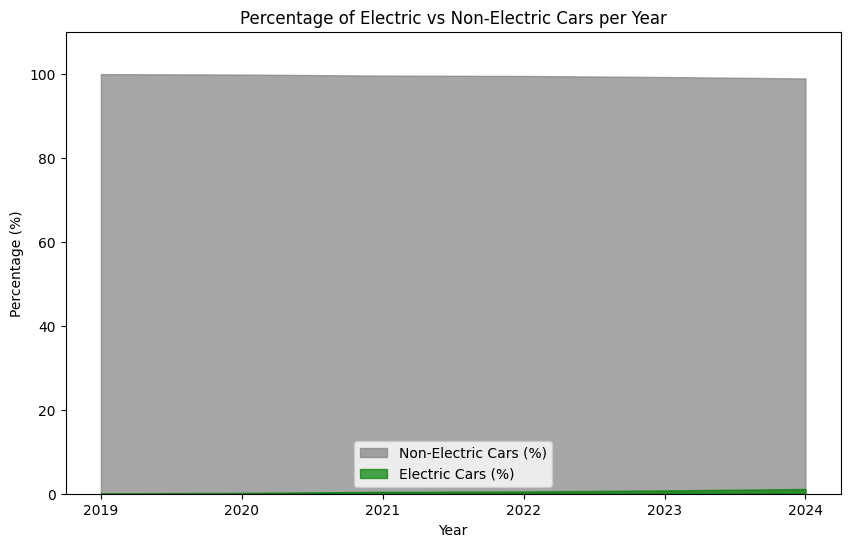

In [ ]:
# Area chart: percentage of electric cars and non-electric cars per year
import matplotlib.pyplot as plt
percentage_electric = (electricity_sum_by_year / total_vehicles_by_year) * 100
percentage_nonelectric = 100 - percentage_electric
plt.figure(figsize=(10, 6))
plt.fill_between(percentage_electric.index, percentage_nonelectric.values, alpha=0.7, color="gray", label="Non-Electric Cars (%)")
plt.fill_between(percentage_electric.index, percentage_electric.values, alpha=0.7, color="green", label="Electric Cars (%)")
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.title('Percentage of Electric vs Non-Electric Cars per Year')
plt.ylim(0, 110)
plt.legend()
plt.show()

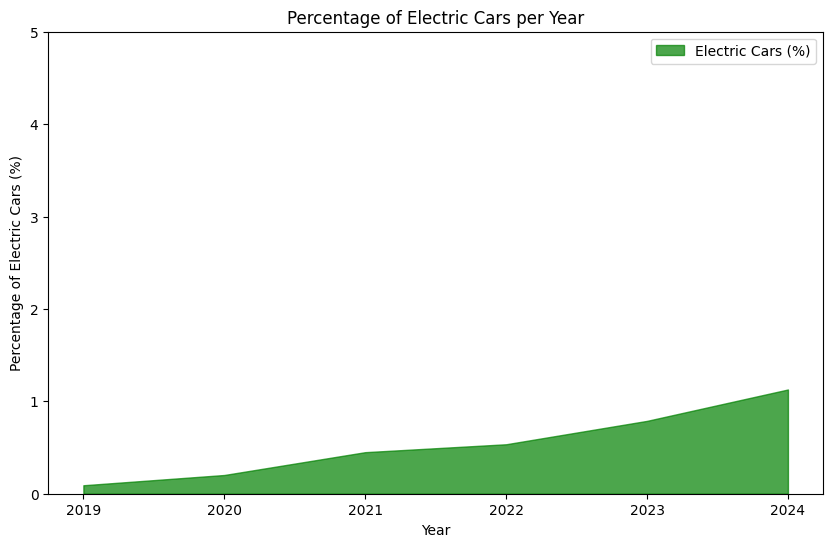

In [ ]:
# Area chart: percentage of electric cars per year
percentage_electric = (electricity_sum_by_year / total_vehicles_by_year) * 100
plt.figure(figsize=(10,6))
plt.fill_between(percentage_electric.index, percentage_electric.values, alpha=0.7, color='green', label='Electric Cars (%)')
plt.xlabel('Year')
plt.ylabel('Percentage of Electric Cars (%)')
plt.title('Percentage of Electric Cars per Year')
plt.ylim(0, 5)
plt.legend()
plt.show()

In [ ]:
# Convert percentage_electric Series to DataFrame and rename column for CSV export
percentage_electric_df = percentage_electric.to_frame()
percentage_electric_df = percentage_electric_df.rename(columns={percentage_electric_df.columns[0]: "percentage"})
percentage_electric_df.to_csv("electric.csv")